## reproducing Fig.3 of Kitade and Kataoka 2026

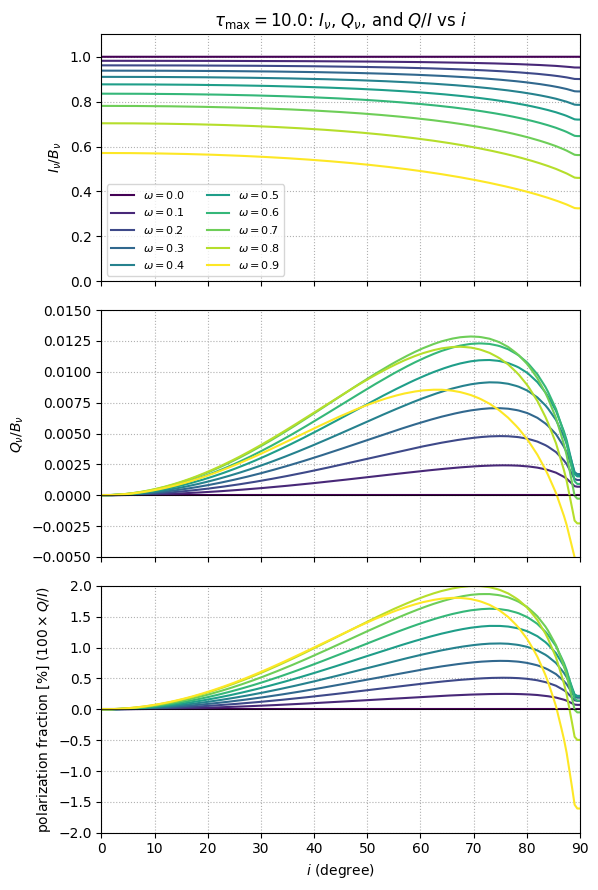

In [4]:
from emergentintensity import emergent_stokes, INTERP_TABLES

import numpy as np
import matplotlib.pyplot as plt

# ========= Parameters =========
tau_fig   = 10.0                         # tau_max used for the figure (e.g., Fig. 3)
omega_arr = np.linspace(0.0, 0.9, 10)    # omega = 0.0, 0.1, ..., 0.9
inc_vals  = np.linspace(0.0, 90.0, 181)  # inclination i = 0–90 deg (0.5 deg steps)

# Make sure tables are loaded
if INTERP_TABLES is None:
    setup_tables()

# ========= Compute emergent I, Q, and "PF" (= Q/I) =========
I_map  = {}
Q_map  = {}
PF_map = {}

for omega in omega_arr:
    I_list  = []
    Q_list  = []
    PF_list = []
    for inc in inc_vals:
        # emergent_stokes(tau_max, omega, inc_deg) -> (I, Q)
        I, Q = emergent_stokes(tau_fig, float(omega), float(inc))
        I = float(I)
        Q = float(Q)
        PF = 0.0 if I == 0.0 else (Q / I)

        I_list.append(I)
        Q_list.append(Q)
        PF_list.append(PF)

    I_map[omega]  = np.array(I_list)
    Q_map[omega]  = np.array(Q_list)
    PF_map[omega] = np.array(PF_list)

# ========= Plotting =========
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(6, 9))
axI, axQ, axP = axes

colors = plt.cm.viridis(np.linspace(0.0, 1.0, len(omega_arr)))

# --- Top panel: I/Bν vs inclination i ---
for omega, c in zip(omega_arr, colors):
    axI.plot(inc_vals, I_map[omega], color=c, label=fr"$\omega={omega:.1f}$")

axI.set_ylabel(r"$I_\nu/B_\nu$")
axI.set_title(fr"$\tau_{{\max}}={tau_fig}$: $I_\nu$, $Q_\nu$, and $Q/I$ vs $i$")
axI.grid(True, ls=":")
axI.legend(ncol=2, fontsize=8, loc="best")
axI.set_xlim(0.0, 90.0)
axI.set_ylim(0.0, 1.1)   # adjust if needed

# --- Middle panel: Q/Bν vs inclination i ---
for omega, c in zip(omega_arr, colors):
    axQ.plot(inc_vals, Q_map[omega], color=c)
axQ.axhline(0.0, color="k", lw=0.5)
axQ.set_ylabel(r"$Q_\nu/B_\nu$")
axQ.grid(True, ls=":")
axQ.set_xlim(0.0, 90.0)
axQ.set_ylim(-0.005, 0.015)  # adjust if needed

# --- Bottom panel: polarization fraction [%] (= 100 * Q/I) vs inclination i ---
for omega, c in zip(omega_arr, colors):
    axP.plot(inc_vals, 100.0 * PF_map[omega], color=c)
axP.axhline(0.0, color="k", lw=0.5)
axP.set_xlabel(r"$i$ (degree)")
axP.set_ylabel(r"polarization fraction [%] ($100\times Q/I$)")
axP.grid(True, ls=":")
axP.set_xlim(0.0, 90.0)
axP.set_ylim(-2.0, 2.0)  # adjust if needed

plt.tight_layout()